In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import warnings

warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv("heart.csv")

print("First Five Records")
print(df.head())

print("\nDataset Shape:", df.shape)

First Five Records
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak
0   63    1   3       145   233    1        0      150      0      2.3
1   37    1   2       130   250    0        1      187      0      3.5
2   41    0   1       130   204    0        0      172      0      1.4
3   56    1   1       120   236    0        1      178      0      0.8
4   57    0   0       120   354    0        1      163      1      0.6

Dataset Shape: (303, 10)


In [3]:
if "target" not in df.columns:

    if "exang" not in df.columns:
        raise ValueError(
            "The dataset must contain either a 'target' "
            "column or an 'exang' column.")

    df["target"] = df["exang"]

    print(
        "\nNo 'target' column found - "
        "created it from 'exang'.")

else:
    print("\nTarget column found in dataset.")


print("\nTarget Values:")
print(sorted(df["target"].unique()))

print("\nTarget Distribution:")
print(df["target"].value_counts())


No 'target' column found - created it from 'exang'.

Target Values:
[np.int64(0), np.int64(1)]

Target Distribution:
target
0    204
1     99
Name: count, dtype: int64


In [4]:
required_columns = [
    "age",
    "sex",
    "cp",
    "restecg",
    "chol",
    "target"]

missing_columns = [
    col for col in required_columns
    if col not in df.columns]

if missing_columns:
    raise ValueError(
        f"Missing columns in heart.csv: {missing_columns}")

model_df = df[required_columns].copy()

In [5]:
model_df = model_df.dropna()

print("\nDataset Shape After Removing Missing Values:")
print(model_df.shape)


Dataset Shape After Removing Missing Values:
(303, 6)


In [6]:
if model_df["age"].nunique() > 5:

    age_bins = pd.cut(
        model_df["age"],
        bins=5)

    model_df["age"] = pd.cut(
        model_df["age"],
        bins=5,
        labels=False)

    print("\nAge Bin Boundaries:")
    print(age_bins.cat.categories)


if model_df["chol"].nunique() > 5:

    chol_bins = pd.cut(
        model_df["chol"],
        bins=5)

    model_df["chol"] = pd.cut(
        model_df["chol"],
        bins=5,
        labels=False)

    print("\nCholesterol Bin Boundaries:")
    print(chol_bins.cat.categories)


Age Bin Boundaries:
IntervalIndex([(28.952, 38.6], (38.6, 48.2], (48.2, 57.8], (57.8, 67.4],
               (67.4, 77.0]],
              dtype='interval[float64, right]')

Cholesterol Bin Boundaries:
IntervalIndex([(125.562, 213.6],   (213.6, 301.2],   (301.2, 388.8],
                 (388.8, 476.4],   (476.4, 564.0]],
              dtype='interval[float64, right]')


In [7]:
model_df = model_df.astype(int)

print("\nProcessed Dataset")
print(model_df.head())


Processed Dataset
   age  sex  cp  restecg  chol  target
0    3    1   3        0     1       0
1    0    1   2        1     1       0
2    1    0   1        0     0       0
3    2    1   1        1     1       0
4    2    0   0        1     2       1


In [8]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

In [9]:
model = DiscreteBayesianNetwork([
    ("age", "target"),
    ("sex", "target"),
    ("cp", "target"),
    ("target", "restecg"),
    ("target", "chol")])

In [10]:
model.fit(
    model_df,
    estimator=DiscreteMLE())

print("\nBayesian Network Created Successfully")


Bayesian Network Created Successfully


In [11]:
for node in model.nodes():

    cpd = model.get_cpds(node)

    print(f"\nCPD of {node.upper()}\n")
    print(cpd)


CPD of AGE

+--------+-----------+
| age(0) | 0.039604  |
+--------+-----------+
| age(1) | 0.234323  |
+--------+-----------+
| age(2) | 0.320132  |
+--------+-----------+
| age(3) | 0.349835  |
+--------+-----------+
| age(4) | 0.0561056 |
+--------+-----------+

CPD of TARGET

+-----------+--------+--------+--------+--------+-----+--------+--------+--------+--------+--------+--------+
| age       | age(0) | age(0) | age(0) | age(0) | ... | age(4) | age(4) | age(4) | age(4) | age(4) | age(4) |
+-----------+--------+--------+--------+--------+-----+--------+--------+--------+--------+--------+--------+
| cp        | cp(0)  | cp(0)  | cp(1)  | cp(1)  | ... | cp(1)  | cp(1)  | cp(2)  | cp(2)  | cp(3)  | cp(3)  |
+-----------+--------+--------+--------+--------+-----+--------+--------+--------+--------+--------+--------+
| sex       | sex(0) | sex(1) | sex(0) | sex(1) | ... | sex(0) | sex(1) | sex(0) | sex(1) | sex(0) | sex(1) |
+-----------+--------+--------+--------+--------+-----+---

In [12]:
print("\nModel Check")

is_valid = model.check_model()

print("Model Valid:", is_valid)

if not is_valid:
    raise ValueError(
        "Model structure or CPDs are invalid.")


Model Check
Model Valid: True


In [13]:
print("\nNodes")
print(list(model.nodes()))

print("\nEdges")
print(list(model.edges()))


Nodes
['age', 'target', 'sex', 'cp', 'restecg', 'chol']

Edges
[('age', 'target'), ('target', 'restecg'), ('target', 'chol'), ('sex', 'target'), ('cp', 'target')]


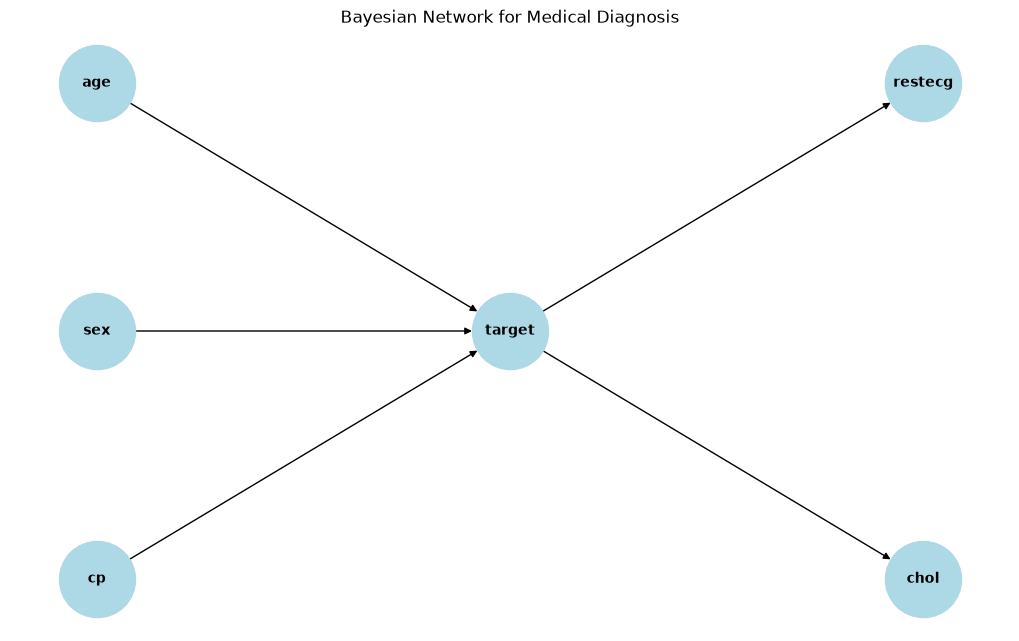

In [14]:
plt.figure(figsize=(10, 6))

pos = {
    "age": (0, 2),
    "sex": (0, 1),
    "cp": (0, 0),
    "target": (2, 1),
    "restecg": (4, 2),
    "chol": (4, 0)}

nx.draw(
    model,
    pos=pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True)

plt.title("Bayesian Network for Medical Diagnosis")

plt.show()


In [15]:
print("\n" + "=" * 50)
print("Bayesian Network Inference")
print("=" * 50)

inference = VariableElimination(model)

print("\nQuery 1: Prior Probability of Target")

result_prior = inference.query(
    variables=["target"])

print(result_prior)


Bayesian Network Inference

Query 1: Prior Probability of Target
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.6551 |
+-----------+---------------+
| target(1) |        0.3449 |
+-----------+---------------+


In [16]:
evidence = {
    "age": 2,
    "sex": 1,
    "cp": 2}

print(
    "\nQuery 2: Probability of Target "
    "Given Patient Information")

try:

    result = inference.query(
        variables=["target"],
        evidence=evidence)

    print("\nMedical Diagnosis Prediction")
    print("Evidence:", evidence)
    print(result)

except Exception as e:

    print("\nInference could not be performed.")
    print("Reason:", e)



Query 2: Probability of Target Given Patient Information

Medical Diagnosis Prediction
Evidence: {'age': 2, 'sex': 1, 'cp': 2}
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.8421 |
+-----------+---------------+
| target(1) |        0.1579 |
+-----------+---------------+


In [17]:
print(
    "\nQuery 3: Given restecg = 1, "
    "What is P(target)?")

try:

    result_3 = inference.query(
        variables=["target"],
        evidence={"restecg": 1})

    print(result_3)

except Exception as e:

    print("Reason:", e)


Query 3: Given restecg = 1, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        0.7003 |
+-----------+---------------+
| target(1) |        0.2997 |
+-----------+---------------+


In [18]:
print(
    "\nQuery 4: Given chol = 4, "
    "What is P(target)?")

try:

    result_4 = inference.query(
        variables=["target"],
        evidence={"chol": 4})

    print(result_4)

except Exception as e:

    print("Reason:", e)


Query 4: Given chol = 4, What is P(target)?
+-----------+---------------+
| target    |   phi(target) |
+===========+===============+
| target(0) |        1.0000 |
+-----------+---------------+
| target(1) |        0.0000 |
+-----------+---------------+


In [19]:
print("\nDiagnosis Inference Complete.")


Diagnosis Inference Complete.
